<a href="https://colab.research.google.com/github/fatouu50/Time-Series-Forecasting-ML/blob/main/Mois_1_Machine_Learning/ML_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1 : charger le fichier

In [1]:
import pandas as pd

df  = pd.read_csv('train.csv')

df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## Step 2 : Mettre la date au bon format et trier

In [2]:
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date')  #fonction pour trier

df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
211816,2013-01-01,7,12,26
832656,2013-01-01,7,46,27
213642,2013-01-01,8,12,54
215468,2013-01-01,9,12,35


## Step 3 : Nettoyer

In [3]:
df.isnull().sum() #valeurs manquantes

,0
date,0
store,0
item,0
sales,0


In [4]:
df.duplicated().sum()  #doublons

np.int64(0)

## Step 4 : Regarder les bases

In [5]:
df['store'].nunique()  #number of unique

10

In [6]:
df['item'].nunique()

50

In [7]:
df['date'].min()

Timestamp('2013-01-01 00:00:00')

In [8]:
df['date'].max()

Timestamp('2017-12-31 00:00:00')

In [9]:
df.shape  #rows & columns

(913000, 4)

In [10]:
df.columns  #noms de toutes les colonnes.

Index(['date', 'store', 'item', 'sales'], dtype='object')

In [11]:
df.dtypes #type of columns

,0
date,datetime64[ns]
store,int64
item,int64
sales,int64


In [12]:
df['sales'].describe()  #résumé statistique

,sales
count,913000.000000
mean,52.250287
std,28.801144
min,0.000000
25%,30.000000
50%,47.000000
75%,70.000000
max,231.000000


In [13]:
df['store'].value_counts() #Compte combien de fois chaque valeur apparaît

,count
store,
1,91300
7,91300
8,91300
9,91300
10,91300
6,91300
2,91300
5,91300
3,91300


## Univarié sur sales (variable quantitative → chiffres + forme)

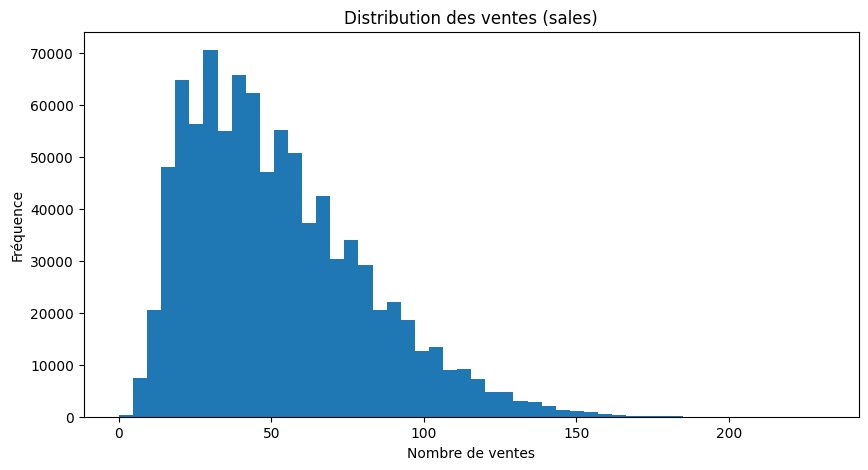

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df['sales'], bins=50)
plt.title('Distribution des ventes (sales)')
plt.xlabel('Nombre de ventes')
plt.ylabel('Fréquence')
plt.show()

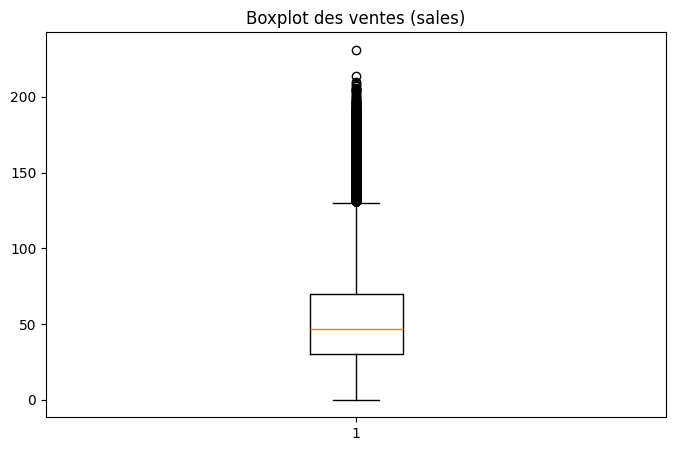

In [15]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['sales'])
plt.title('Boxplot des ventes (sales)')
plt.show()

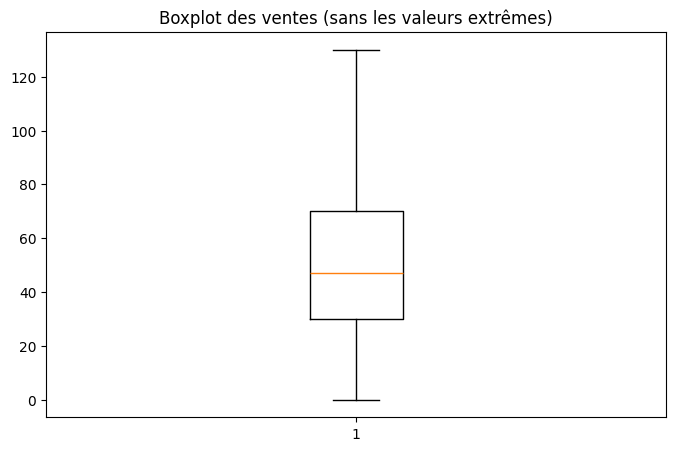

In [16]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['sales'], showfliers=False)  # showfliers=False cache les points outliers, pour se concentrer sur la boîte principale (25%-75%).
plt.title('Boxplot des ventes (sans les valeurs extrêmes)')
plt.show()

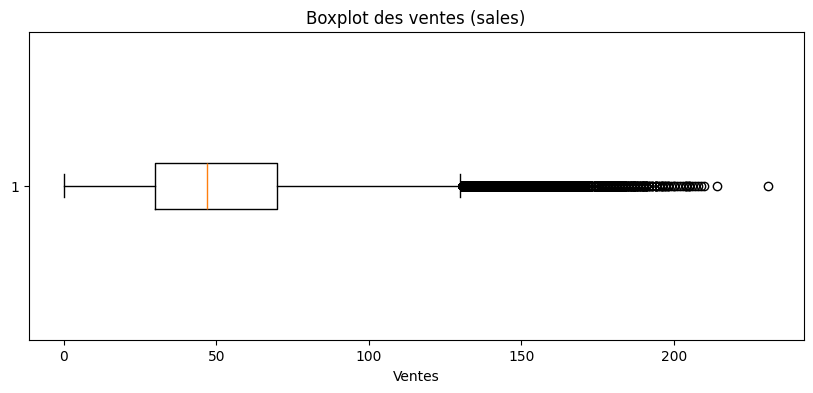

In [17]:
plt.figure(figsize=(10, 4)) #Boxplot horizontal (souvent plus lisible) :
plt.boxplot(df['sales'], vert=False)
plt.title('Boxplot des ventes (sales)')
plt.xlabel('Ventes')
plt.show()

## Univarié sur date (vérifier qu'aucun jour ne manque)

In [18]:
date_debut = df['date'].min()
date_fin = df['date'].max()
nb_jours_theorique = (date_fin - date_debut).days + 1
nb_jours_reels = df['date'].nunique()

print("Date de début :", date_debut)
print("Date de fin :", date_fin)
print("Jours théoriques :", nb_jours_theorique)
print("Jours réels présents :", nb_jours_reels)

Date de début : 2013-01-01 00:00:00
Date de fin : 2017-12-31 00:00:00
Jours théoriques : 1826
Jours réels présents : 1826


## Univarié sur store (variable catégorielle → comptage)

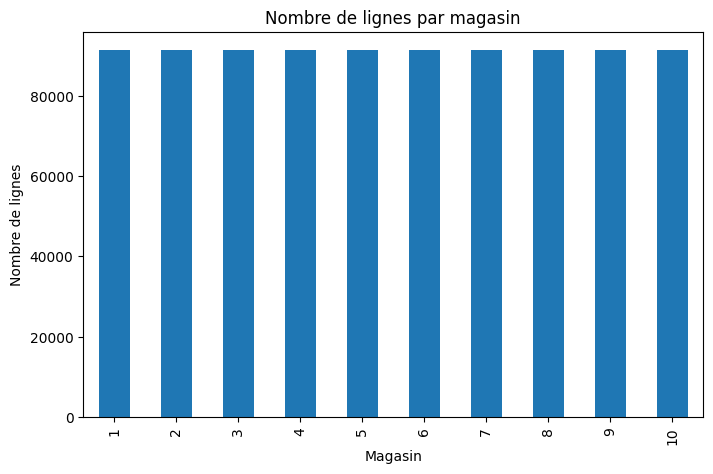

In [19]:
plt.figure(figsize=(8, 5))
df['store'].value_counts().sort_index().plot(kind='bar')
plt.title("Nombre de lignes par magasin")
plt.xlabel('Magasin')
plt.ylabel('Nombre de lignes')
plt.show()

### Petit rappel de la logique derrière chaque variable :

sales → quantité → on regarde distribution, moyenne, outliers.

date → temporel → on vérifie continuité, pas de trou.

store et item → catégories → on regarde combien de valeurs différentes, et

combien de fois chacune apparaît.

# On passe à l'analyse bivariée.

Rappel : ici on compare sales avec une autre variable, pour voir comment les
ventes changent selon cette variable.

## sales selon le jour de la semaine

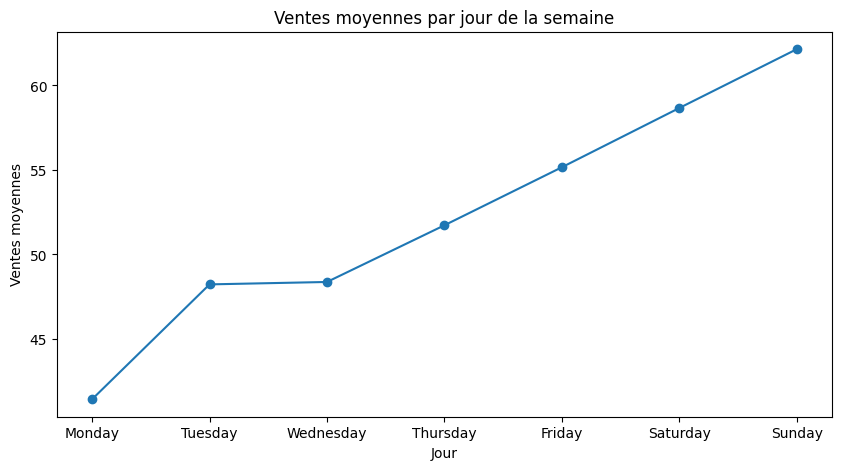

In [20]:
df['jour_semaine'] = df['date'].dt.day_name()  #jour de la semaine

ventes_par_jour_semaine = df.groupby('jour_semaine')['sales'].mean()

ordre = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventes_par_jour_semaine = ventes_par_jour_semaine.reindex(ordre)

plt.figure(figsize=(10, 5))
ventes_par_jour_semaine.plot(kind='line', marker='o')
plt.title('Ventes moyennes par jour de la semaine')
plt.xlabel('Jour')
plt.ylabel('Ventes moyennes')
plt.show()

## sales selon le mois (saisonnalité annuelle)

<Figure size 1000x500 with 0 Axes>

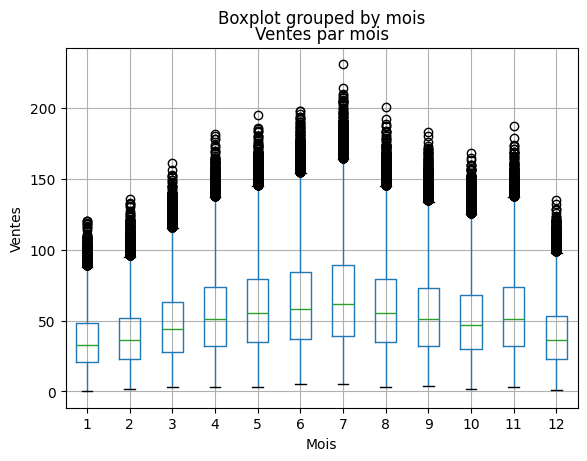

In [21]:
df['mois'] = df['date'].dt.month  #mois de l'année

plt.figure(figsize=(10, 5))
df.boxplot(column='sales', by='mois')
plt.title('Ventes par mois')
plt.xlabel('Mois')
plt.ylabel('Ventes')
plt.show()

## sales selon le magasin (store)

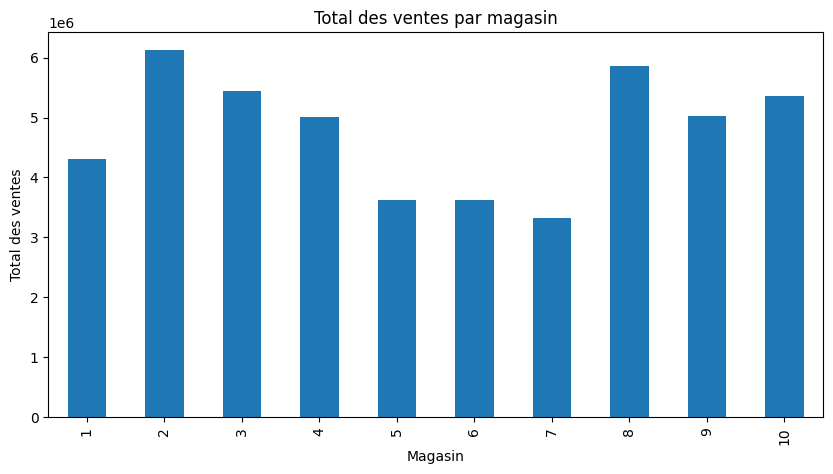

In [22]:
ventes_par_magasin = df.groupby('store')['sales'].sum()

plt.figure(figsize=(10, 5))
ventes_par_magasin.plot(kind='bar')
plt.title('Total des ventes par magasin')
plt.xlabel('Magasin')
plt.ylabel('Total des ventes')
plt.show()

## sales selon l'article (item) — top et flop

In [23]:
ventes_par_article = df.groupby('item')['sales'].sum().sort_values(ascending=False)

print("Top 5 articles les plus vendus :")
print(ventes_par_article.head())

print("\nTop 5 articles les moins vendus :")
print(ventes_par_article.tail())

Top 5 articles les plus vendus :
item
15    1607442
28    1604713
13    1539621
18    1538876
25    1473334
Name: sales, dtype: int64

Top 5 articles les moins vendus :
item
4     401907
47    401781
41    401759
1     401384
5     335230
Name: sales, dtype: int64


## Logique derrière chaque graphique :

Jour de semaine → comportement client (week-end vs semaine).

Mois → saisonnalité (été/hiver, fêtes).

Magasin → comparaison de performance entre magasins.

Article → comparaison de performance entre produits.

# SEMAINE 2 — DÉCOUPAGE TEMPOREL

## 6. Train / Validation / Test Split

In [24]:
df = df.sort_values(by='date').reset_index(drop=True)

date_val = "2017-07-01"
date_test = "2017-10-01"

train_df = df[df['date'] < date_val]
val_df = df[(df['date'] >= date_val) & (df['date'] < date_test)]
test_df = df[df['date'] >= date_test]

print(f"Train set : {train_df.shape[0]:,} lignes")
print(f"Validation set : {val_df.shape[0]:,} lignes")
print(f"Test set : {test_df.shape[0]:,} lignes")

Train set : 821,000 lignes
Validation set : 46,000 lignes
Test set : 46,000 lignes


### FEATURE ENGINEERING

### 7. Variables Calendaires

In [25]:
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.day_of_week
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

In [29]:
df[['date', 'month', 'dayofweek', 'is_weekend']].head(50)

,date,month,dayofweek,is_weekend
0,2013-01-01,1,1,0
1,2013-01-01,1,1,0
2,2013-01-01,1,1,0
3,2013-01-01,1,1,0
4,2013-01-01,1,1,0
5,2013-01-01,1,1,0
6,2013-01-01,1,1,0
7,2013-01-01,1,1,0
8,2013-01-01,1,1,0
9,2013-01-01,1,1,0


In [30]:
df[['date', 'store', 'item', 'month', 'dayofweek', 'is_weekend']].head(50)

,date,store,item,month,dayofweek,is_weekend
0,2013-01-01,1,1,1,1,0
1,2013-01-01,2,38,1,1,0
2,2013-01-01,3,35,1,1,0
3,2013-01-01,3,37,1,1,0
4,2013-01-01,2,37,1,1,0
5,2013-01-01,1,37,1,1,0
6,2013-01-01,5,37,1,1,0
7,2013-01-01,10,36,1,1,0
8,2013-01-01,9,36,1,1,0
9,2013-01-01,6,37,1,1,0


In [31]:
df[['date', 'store', 'item', 'month', 'dayofweek', 'is_weekend']].sample(20)  #sample:hasard

,date,store,item,month,dayofweek,is_weekend
82159,2013-06-14,1,48,6,4,0
663837,2016-08-20,7,2,8,5,1
466709,2015-07-23,1,19,7,3,0
206075,2014-02-17,9,45,2,0,0
325875,2014-10-14,2,2,10,1,0
255458,2014-05-26,7,33,5,0,0
494609,2015-09-17,4,1,9,3,0
53138,2013-04-17,3,9,4,2,0
441778,2015-06-03,8,16,6,2,0
663059,2016-08-19,1,31,8,4,0


### 8. Lags

In [33]:
df = df.sort_values(by=['store', 'item', 'date']).reset_index(drop=True)

df['lag_1'] = df.groupby(['store', 'item'])['sales'].shift(1)  #décale les valeurs de 7 lignes  vers le bas .
df['lag_7'] = df.groupby(['store', 'item'])['sales'].shift(7)
df['lag_14'] = df.groupby(['store', 'item'])['sales'].shift(14)

In [34]:
df[['date', 'store', 'item', 'sales', 'lag_1', 'lag_7', 'lag_14']].sample(20)

,date,store,item,sales,lag_1,lag_7,lag_14
830108,2016-01-10,10,5,16,12.0,15.0,21.0
153054,2017-02-05,2,34,29,33.0,25.0,32.0
471886,2015-02-18,6,9,43,26.0,31.0,35.0
650415,2013-12-26,8,7,44,37.0,42.0,29.0
89662,2013-07-08,1,50,43,71.0,34.0,46.0
114286,2015-12-11,2,13,91,90.0,74.0,133.0
106331,2014-02-28,2,9,41,46.0,48.0,43.0
306339,2016-10-29,4,18,103,115.0,91.0,113.0
694647,2015-02-07,8,31,60,48.0,56.0,64.0
912364,2016-04-05,10,50,72,52.0,73.0,58.0


### 9. Moyennes Glissantes

In [35]:
df['rolling_mean_7'] = df.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(window=7).mean())
df['rolling_mean_30'] = df.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(window=30).mean())

Le cœur du calcul :  x.shift(1).rolling(window=7).mean()

C'est 3 actions enchaînées :

1. x.shift(1) → on décale d'un jour vers le bas.

→ Pourquoi ? Pour ne pas tricher. Si on prédit les ventes d'aujourd'hui, on ne peut pas utiliser les ventes d'aujourd'hui dans le calcul. On utilise uniquement le passé.

2. .rolling(window=7)

→ on prend une fenêtre glissante de 7 jours.

→ Concrètement : pour chaque ligne, Python regarde les 7 jours précédents.

3. .mean()

 → on calcule la moyenne de ces 7 jours.

In [36]:
df[['date', 'store', 'item', 'sales', 'rolling_mean_7', 'rolling_mean_30']].sample(20)

,date,store,item,sales,rolling_mean_7,rolling_mean_30
94545,2016-11-20,2,2,104,89.428571,86.366667
274802,2015-06-22,4,1,30,27.428571,28.000000
878225,2017-10-12,10,31,66,66.857143,72.700000
316862,2015-08-23,4,24,93,76.857143,82.700000
826100,2015-01-19,10,3,19,27.571429,27.600000
172362,2014-12-20,2,45,86,73.000000,84.066667
655153,2016-12-16,8,9,57,50.142857,64.033333
713974,2013-01-09,8,42,23,23.857143,NaN
253373,2016-10-17,3,39,39,52.857143,54.533333
856811,2014-02-22,10,20,44,35.571429,36.533333


###  Actualisation du découpage temporel et traitement des valeurs manquantes

### 10. Réapplication du découpage + Nettoyage des NaN

In [37]:
df = df.dropna()

date_val = "2017-07-01"
date_test = "2017-10-01"

train_df = df[df['date'] < date_val]
val_df = df[(df['date'] >= date_val) & (df['date'] < date_test)]
test_df = df[df['date'] >= date_test]

print(f"Train set : {train_df.shape[0]:,} lignes")
print(f"Validation set : {val_df.shape[0]:,} lignes")
print(f"Test set : {test_df.shape[0]:,} lignes")

Train set : 806,000 lignes
Validation set : 46,000 lignes
Test set : 46,000 lignes


### 11. Définition de X et y

In [38]:
features = ['store', 'item', 'month', 'dayofweek', 'is_weekend',
            'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_30']

X_train = train_df[features]       #caractéristiques / features
y_train = train_df['sales']

X_val = val_df[features]
y_val = val_df['sales']  #cible / target

X_test = test_df[features]
y_test = test_df['sales']

print("X_train :", X_train.shape)
print("X_val :", X_val.shape)
print("X_test :", X_test.shape)

X_train : (806000, 10)
X_val : (46000, 10)
X_test : (46000, 10)


### 12. Baseline

In [39]:
from sklearn.metrics import mean_absolute_error

# La baseline : on prédit que demain = les ventes d'il y a 7 jours
y_pred_baseline = X_val['lag_7']

# On calcule l'erreur
mae_baseline = mean_absolute_error(y_val, y_pred_baseline)
print(f"MAE Baseline : {mae_baseline:.2f}")

MAE Baseline : 9.35


### 13. XGBoost

In [40]:
from xgboost import XGBRegressor

# 1. Créer le modèle
model_xgb = XGBRegressor(n_estimators=100, random_state=42)

# 2. Entraîner sur le Train set
model_xgb.fit(X_train, y_train)

# 3. Prédire sur le Validation set
y_pred_xgb = model_xgb.predict(X_val)

# 4. Calculer l'erreur
mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
print(f"MAE Baseline : {mae_baseline:.2f}")
print(f"MAE XGBoost  : {mae_xgb:.2f}")

MAE Baseline : 9.35
MAE XGBoost  : 6.73


### 14. Visualisation XGBoost vs Réalité

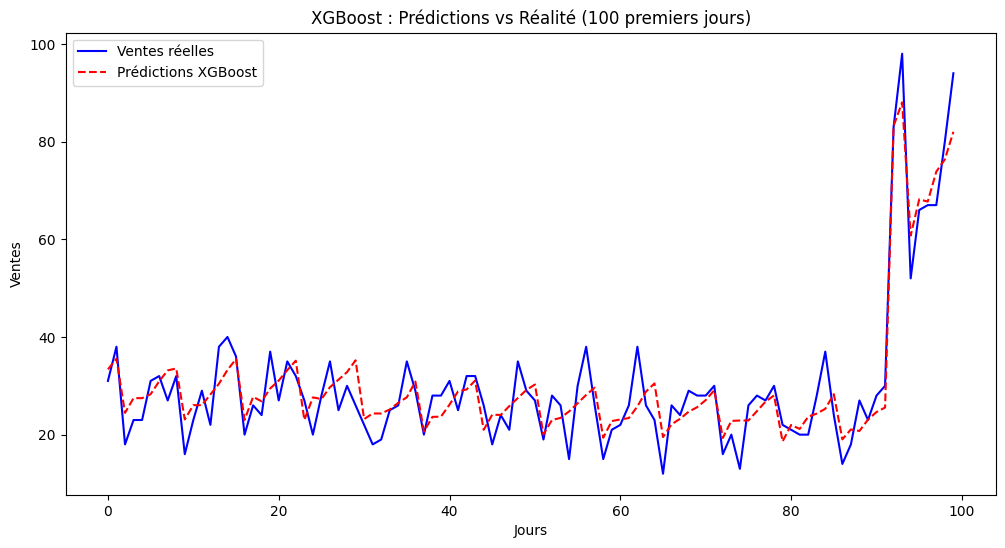

In [45]:
import matplotlib.pyplot as plt

# On prend 100 jours pour que le graphique soit lisible
plt.figure(figsize=(12, 6))
plt.plot(y_val.values[:100], label='Ventes réelles', color='blue')
plt.plot(y_pred_xgb[:100], label='Prédictions XGBoost', color='red', linestyle='--')
plt.title('XGBoost : Prédictions vs Réalité (100 premiers jours)')
plt.xlabel('Jours')
plt.ylabel('Ventes')
plt.legend()
plt.show()

### 15. LightGBM

In [46]:
from lightgbm import LGBMRegressor

# 1. Créer le modèle
model_lgbm = LGBMRegressor(n_estimators=100, random_state=42)

# 2. Entraîner sur le Train set
model_lgbm.fit(X_train, y_train)

# 3. Prédire sur le Validation set
y_pred_lgbm = model_lgbm.predict(X_val)

# 4. Calculer l'erreur
mae_lgbm = mean_absolute_error(y_val, y_pred_lgbm)

print(f"MAE Baseline : {mae_baseline:.2f}")
print(f"MAE XGBoost  : {mae_xgb:.2f}")
print(f"MAE LightGBM : {mae_lgbm:.2f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030579 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1146
[LightGBM] [Info] Number of data points in the train set: 806000, number of used features: 10
[LightGBM] [Info] Start training from score 51.632886
MAE Baseline : 9.35
MAE XGBoost  : 6.73
MAE LightGBM : 6.79


### 16. Feature Importance

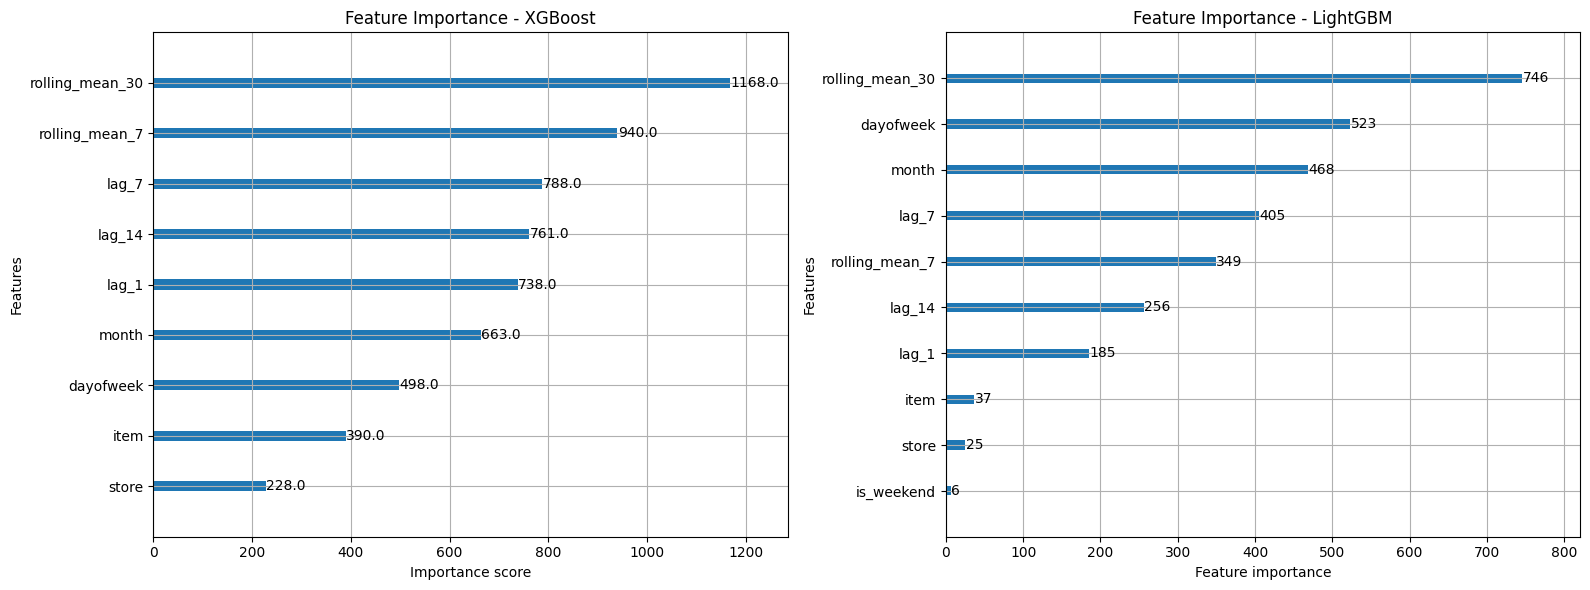

In [47]:
from xgboost import plot_importance

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost
plot_importance(model_xgb, ax=axes[0], title='Feature Importance - XGBoost')

# LightGBM
from lightgbm import plot_importance as lgbm_plot_importance
lgbm_plot_importance(model_lgbm, ax=axes[1], title='Feature Importance - LightGBM')

plt.tight_layout()
plt.show()

### 17. Évaluation Finale sur le Test Set

In [48]:
# On prend le meilleur modèle (XGBoost) et on le teste sur les données cachées
y_pred_final = model_xgb.predict(X_test)

mae_final = mean_absolute_error(y_test, y_pred_final)

print(f"MAE Baseline        : {mae_baseline:.2f}")
print(f"MAE XGBoost (val)   : {mae_xgb:.2f}")
print(f"MAE XGBoost (test)  : {mae_final:.2f}")

MAE Baseline        : 9.35
MAE XGBoost (val)   : 6.73
MAE XGBoost (test)  : 6.20


### 18. Graphique Final

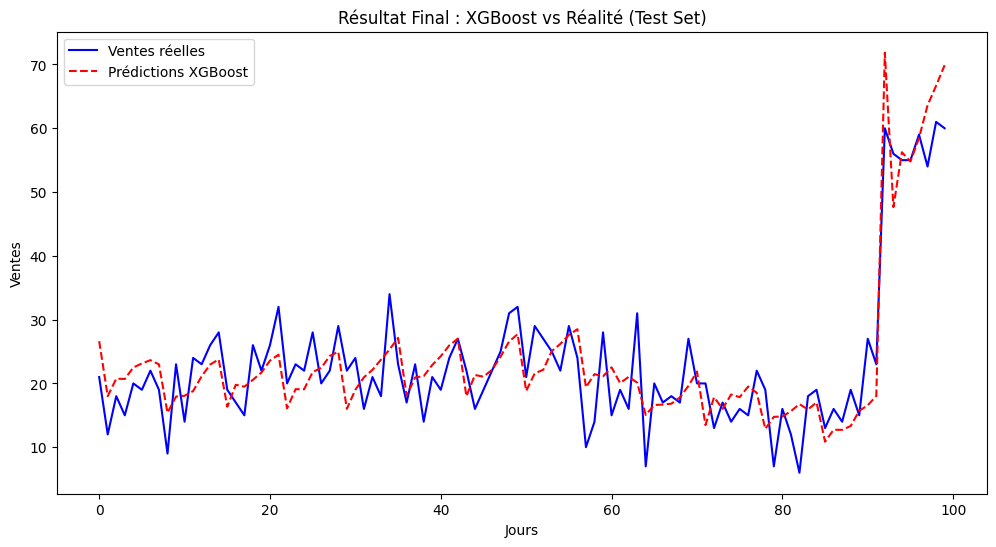

In [49]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:100], label='Ventes réelles', color='blue')
plt.plot(y_pred_final[:100], label='Prédictions XGBoost', color='red', linestyle='--')
plt.title('Résultat Final : XGBoost vs Réalité (Test Set)')
plt.xlabel('Jours')
plt.ylabel('Ventes')
plt.legend()
plt.show()